In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from project_root import PROJECT_ROOT, DATASETS_ROOT

In [7]:
ds_root = DATASETS_ROOT / "elephants/identity/dataset/v4"
images = [f for f in ds_root.glob("**/*.jpg")]
images = [f.relative_to(ds_root) for f in images]
images = [list(f.parts) for f in images]
print(images[0])

df = pd.DataFrame(data={f"part{i}": [f[i] for f in images] for i in range(5)})
df

['01_Chandra', 'zag_elp_cam_018', '2025-01-26', '000144', 'zag_elp_cam_018_20250126_230153_t144_501.jpg']


,part0,part1,part2,part3,part4
0,01_Chandra,zag_elp_cam_018,2025-01-26,000144,zag_elp_cam_018_20250126_230153_t144_501.jpg
1,01_Chandra,zag_elp_cam_018,2025-01-26,000144,zag_elp_cam_018_20250126_230309_t144_821.jpg
2,01_Chandra,zag_elp_cam_018,2025-01-26,000144,zag_elp_cam_018_20250126_230241_t144_701.jpg
3,01_Chandra,zag_elp_cam_018,2025-01-26,000144,zag_elp_cam_018_20250126_230314_t144_841.jpg
4,01_Chandra,zag_elp_cam_018,2025-01-26,000144,zag_elp_cam_018_20250126_230119_t144_361.jpg
...,...,...,...,...,...
19528,05_Thai,zag_elp_cam_016,2025-04-11,000123,zag_elp_cam_016_20250411_214318_t123_521.jpg
19529,05_Thai,zag_elp_cam_016,2025-04-11,000123,zag_elp_cam_016_20250411_214059_t123_81.jpg
19530,05_Thai,zag_elp_cam_016,2025-04-11,000123,zag_elp_cam_016_20250411_214105_t123_101.jpg
19531,05_Thai,zag_elp_cam_016,2025-04-11,000123,zag_elp_cam_016_20250411_214052_t123_61.jpg


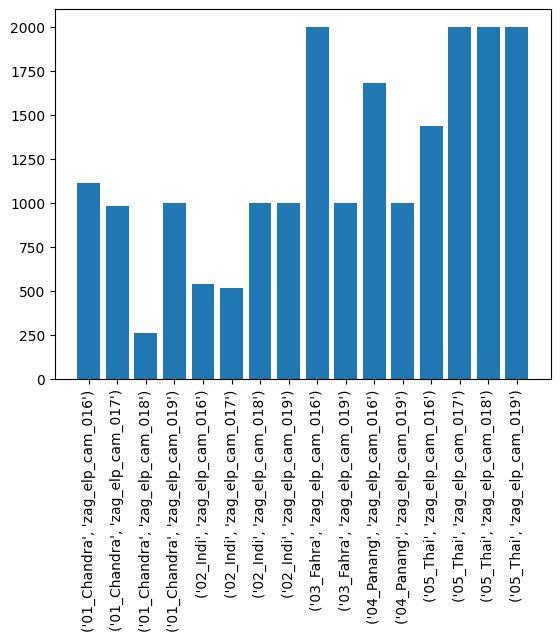

In [8]:
fig, axs = plt.subplots(1, 1)
ax = axs

dfg = df.groupby(["part0", "part1"])["part4"].count()
dfg
ax.bar([str(i) for i in dfg.index], dfg.values)
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90)
plt.show()

In [4]:
day_paths = [
    str(Path(*k)) for k in df.groupby(["part0", "part1", "part2"]).groups.keys()
]
day_paths

['01_Chandra/zag_elp_cam_016/2025-01-25',
 '01_Chandra/zag_elp_cam_016/2025-01-26',
 '01_Chandra/zag_elp_cam_016/2025-04-11',
 '01_Chandra/zag_elp_cam_017/2025-01-26',
 '01_Chandra/zag_elp_cam_017/2025-04-11',
 '01_Chandra/zag_elp_cam_018/2025-01-26',
 '01_Chandra/zag_elp_cam_019/2025-01-25',
 '02_Indi/zag_elp_cam_016/2025-01-25',
 '02_Indi/zag_elp_cam_016/2025-01-26',
 '02_Indi/zag_elp_cam_016/2025-04-11',
 '02_Indi/zag_elp_cam_017/2025-01-26',
 '02_Indi/zag_elp_cam_017/2025-04-11',
 '02_Indi/zag_elp_cam_018/2025-01-26',
 '02_Indi/zag_elp_cam_019/2025-01-25',
 '03_Fahra/zag_elp_cam_016/2025-01-25',
 '03_Fahra/zag_elp_cam_016/2025-01-26',
 '03_Fahra/zag_elp_cam_019/2025-01-25',
 '04_Panang/zag_elp_cam_016/2025-01-25',
 '04_Panang/zag_elp_cam_016/2025-01-26',
 '04_Panang/zag_elp_cam_019/2025-01-25',
 '05_Thai/zag_elp_cam_016/2025-01-25',
 '05_Thai/zag_elp_cam_016/2025-01-26',
 '05_Thai/zag_elp_cam_016/2025-04-11',
 '05_Thai/zag_elp_cam_017/2025-01-25',
 '05_Thai/zag_elp_cam_017/2025-01-

In [5]:
from delete_similar_images import delete_similar_images

for p in day_paths:
    delete_similar_images(ds_root/p, 1000)

 100% |███████████████| 1000/1000 [69.6ms elapsed, 0s remaining, 14.4K samples/s]  
Dataset at /home/dherrera/data/elephants/identity/dataset/v4/01_Chandra/zag_elp_cam_016/2025-01-25 has 1000 images
Computing embeddings...
 100% |███████████████| 1000/1000 [1.0s elapsed, 0s remaining, 995.4 samples/s]         
Computing uniqueness...
Generating index for 1000 embeddings...
Index complete
Uniqueness computation complete
Too few files in directory (1000, keeping all of them)
 100% |█████████████████████| 4/4 [5.6ms elapsed, 0s remaining, 718.3 samples/s]     
Dataset at /home/dherrera/data/elephants/identity/dataset/v4/01_Chandra/zag_elp_cam_016/2025-01-26 has 4 images
Computing embeddings...
 100% |█████████████████████| 4/4 [416.3ms elapsed, 0s remaining, 10.1 samples/s] 
Computing uniqueness...
Generating index for 4 embeddings...
Index complete
Uniqueness computation complete
Too few files in directory (4, keeping all of them)
 100% |█████████████████| 107/107 [13.0ms elapsed, 0s rem

100%|██████████| 271/271 [00:00<00:00, 130126.66it/s]

 100% |█████████████████| 453/453 [39.6ms elapsed, 0s remaining, 11.4K samples/s]  
Dataset at /home/dherrera/data/elephants/identity/dataset/v4/02_Indi/zag_elp_cam_016/2025-01-25 has 453 images
Computing embeddings...


 100% |█████████████████| 453/453 [451.3ms elapsed, 0s remaining, 1.1K samples/s]   
Computing uniqueness...
Generating index for 453 embeddings...
Index complete
Uniqueness computation complete
Too few files in directory (453, keeping all of them)
 100% |███████████████████| 32/32 [8.3ms elapsed, 0s remaining, 3.8K samples/s]       
Dataset at /home/dherrera/data/elephants/identity/dataset/v4/02_Indi/zag_elp_cam_016/2025-01-26 has 32 images
Computing embeddings...
 100% |███████████████████| 32/32 [349.9ms elapsed, 0s remaining, 91.5 samples/s]      
Computing uniqueness...
Generating index for 32 embeddings...
Index complete
Uniqueness computation complete
Too few files in directory (32, keeping all of them)
 100% |███████████████████| 53/53 [19.9ms elapsed, 0s remaining, 2.7K samples/s]      
Dataset at /home/dherrera/data/elephants/identity/dataset/v4/02_Indi/zag_elp_cam_016/2025-04-11 has 53 images
Computing embeddings...
 100% |███████████████████| 53/53 [572.0ms elapsed, 0s rema

100%|██████████| 1487/1487 [00:00<00:00, 129582.39it/s]

...

 100% |███████████████| 1061/1061 [571.8ms elapsed, 0s remaining, 1.9K samples/s]       
Computing uniqueness...
Generating index for 1061 embeddings...
Index complete
Uniqueness computation complete


100%|██████████| 61/61 [00:00<00:00, 57559.63it/s]

   0% ||--------------|    1/4336 [5.0ms elapsed, 21.7s remaining, 199.7 samples/s] 

 100% |███████████████| 4336/4336 [398.8ms elapsed, 0s remaining, 10.9K samples/s]     
Dataset at /home/dherrera/data/elephants/identity/dataset/v4/05_Thai/zag_elp_cam_019/2025-04-11 has 4336 images
Computing embeddings...
 100% |███████████████| 4336/4336 [1.2s elapsed, 0s remaining, 4.8K samples/s]         
Computing uniqueness...
Generating index for 4336 embeddings...
Index complete
Uniqueness computation complete


100%|██████████| 3336/3336 [00:00<00:00, 52809.52it/s]
